In [13]:
import json
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from mighty.mighty_utils.plotting import make_generalization_plot

sns.set_theme(style="whitegrid")

## First off: Let's visualize our Context Sets

In [14]:
train_contexts = []
eval_contexts = []
for mode in  ["a", "b", "c"]:
    with open(f"carl_generalization_example/context_sets/train_contexts_{mode}.json", "r") as f:
        trainc = json.load(f)
    with open(f"carl_generalization_example/context_sets/eval_contexts_{mode}.json", "r") as f:
        evalc = json.load(f)

    trainc = pd.DataFrame(trainc).transpose()
    trainc["mode"] = mode
    train_contexts.append(trainc)

    evalc = pd.DataFrame(evalc).transpose()
    evalc["mode"] = mode
    eval_contexts.append(evalc)

train_contexts = pd.concat(train_contexts)
eval_contexts = pd.concat(eval_contexts)
with open(f"carl_generalization_example/context_sets/test_contexts.json", "r") as f:
    testc = json.load(f)
test_contexts = pd.DataFrame(testc).transpose()

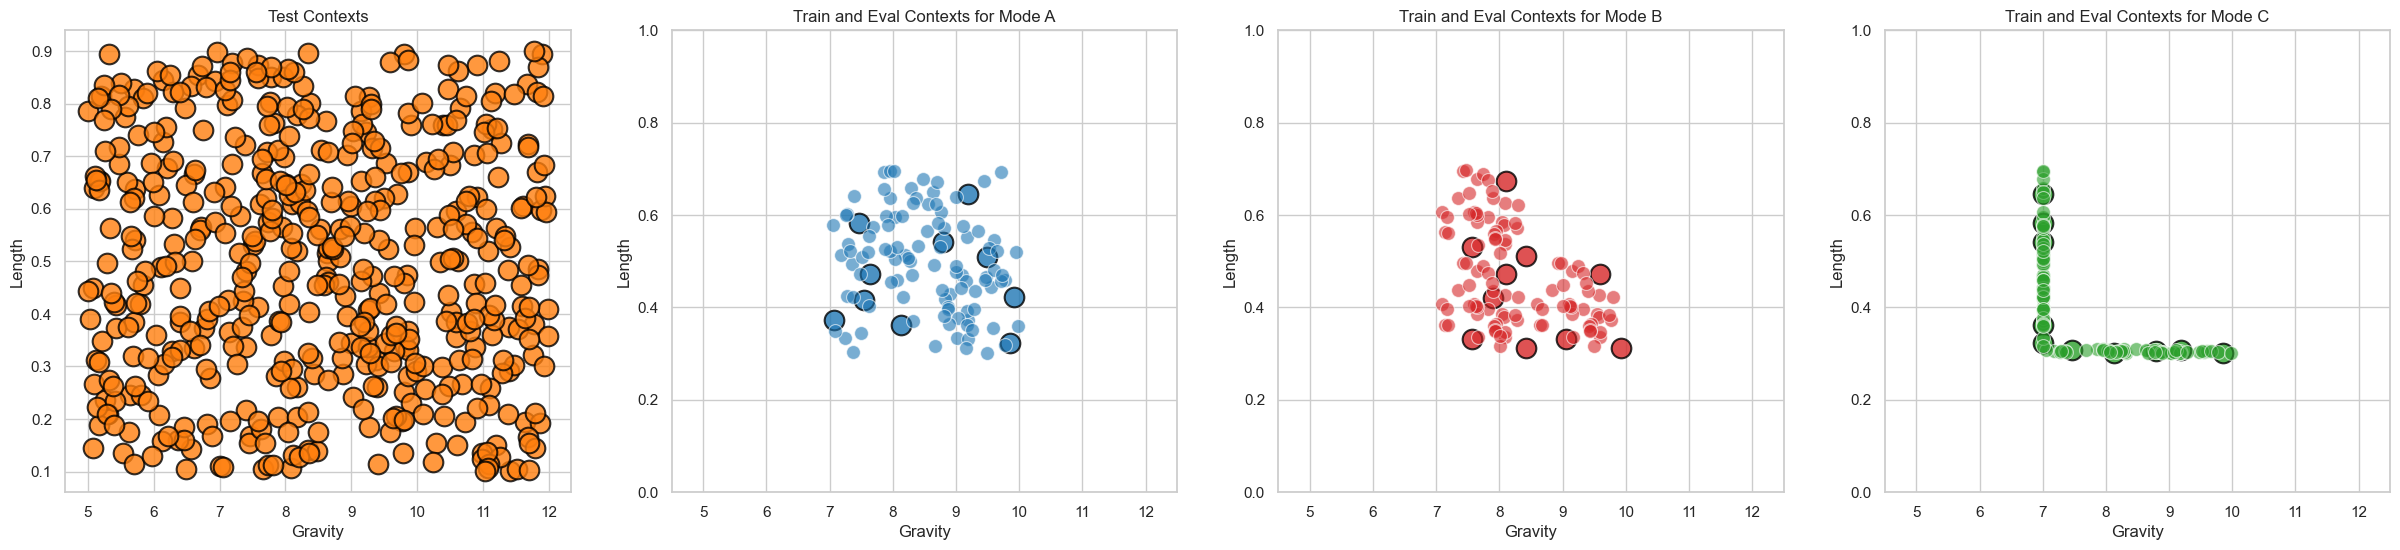

In [15]:
f, axes = plt.subplots(1, 4, figsize=(30, 6))
sns.scatterplot(data=test_contexts, x="gravity", y="length", s=200, edgecolor="black", color="tab:orange", linewidth=1.5, alpha=0.8, ax=axes[0])
axes[0].set_title("Test Contexts")
axes[0].set_xlabel("Gravity")
axes[0].set_ylabel("Length")

colors = {"a": "tab:blue", "b": "tab:red", "c": "tab:green"}
for i, mode in enumerate(["a", "b", "c"]):
    sns.scatterplot(data=train_contexts[train_contexts["mode"] == mode], x="gravity", y="length", s=200, edgecolor="black", color=colors[mode], linewidth=1.5, alpha=0.8, ax=axes[i+1])
    sns.scatterplot(data=eval_contexts[eval_contexts["mode"] == mode], x="gravity", y="length", s=100, color=colors[mode], alpha=0.6, ax=axes[i+1])
    axes[i+1].set_title(f"Train and Eval Contexts for Mode {mode.capitalize()}")
    axes[i+1].set_xlabel("Gravity")
    axes[i+1].set_ylabel("Length")
    axes[i+1].set_ylim(0, 1)
    axes[i+1].set_xlim(4.5, 12.5)


## Next: Check out Training Performance

In [16]:
train_performances = []
eval_performances = []
for mode in  ["a", "b", "c"]:
    train_results = pd.read_csv(f"carl_generalization_example/carl_cartpole_generalization_mode_{mode}/seed_42/results.csv")
    eval_results = pd.read_csv(f"carl_generalization_example/carl_cartpole_generalization_mode_{mode}/seed_42/eval_results.csv")
    train_results["mode"] = mode
    eval_results["mode"] = mode
    train_performances.append(train_results)
    eval_performances.append(eval_results)
train_performances = pd.concat(train_performances)
eval_performances = pd.concat(eval_performances)

Text(0, 0.5, 'Mean Evaluation Reward')

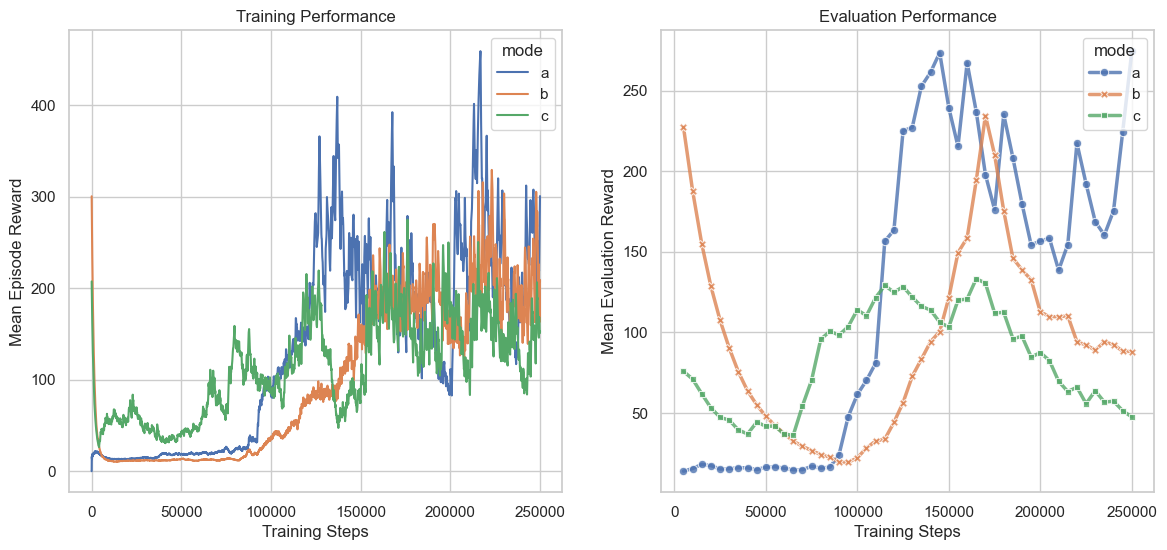

In [17]:
f, axes = plt.subplots(1, 2, figsize=(14, 6))
train_performances["smooth_reward"] = train_performances["mean_episode_reward"].ewm(span=2500).mean()
eval_performances["smooth_reward"] = eval_performances["mean_eval_reward"].ewm(span=10).mean()
sns.lineplot(data=train_performances, x="step", y="smooth_reward", hue="mode", ax=axes[0])
axes[0].set_xlabel("Training Steps")
axes[0].set_ylabel("Mean Episode Reward")
axes[0].set_title("Training Performance")
sns.lineplot(data=eval_performances, x="step", y="smooth_reward", hue="mode", style="mode", markers=True, dashes=False, linewidth=2.5, alpha=0.8, ax=axes[1])
axes[1].set_title("Evaluation Performance")
axes[1].set_xlabel("Training Steps")
axes[1].set_ylabel("Mean Evaluation Reward")

## Lastly: Look at Generalization Capabilities

In [18]:
test_performances = []
for mode in  ["a", "b", "c"]:
    test_results = pd.read_csv(f"carl_generalization_example/carl_cartpole_generalization_mode_{mode}/testing_seed_42/eval_results.csv")
    test_results["mode"] = mode
    test_performances.append(test_results)
test_performances = pd.concat(test_performances)
test_performances.drop(columns=["step", "mean_eval_step_reward", "eval_episodes", "Unnamed: 0"], inplace=True)
test_contexts_relevant_only = test_contexts.drop(columns=["masscart", "masspole", "tau", "force_mag", "initial_state_lower", "initial_state_upper"])
test_contexts_relevant_only["gravity"] = test_contexts_relevant_only["gravity"].astype(float)
test_contexts_relevant_only["length"] = test_contexts_relevant_only["length"].astype(float)
test_contexts_relevant_only["context_id"] = test_contexts_relevant_only.index.astype(int)

merged_test_performances = test_performances.merge(test_contexts_relevant_only, left_on='instances', right_on='context_id')
# If we would have multiple seeds, now we would average over them
# Since we don't in this simple example, we skip this steps and directly drop the seed column
merged_test_performances.drop(columns=["seed"], inplace=True)

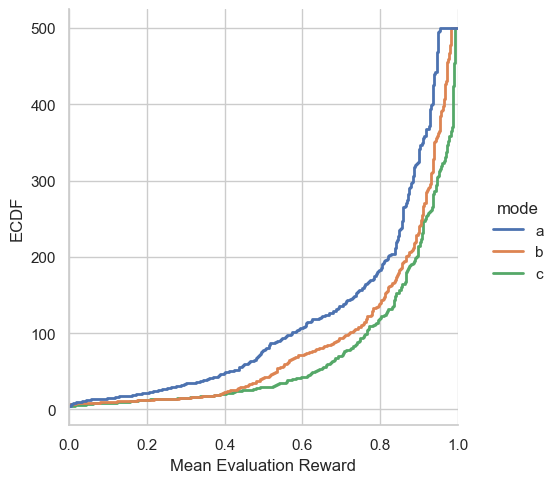

In [19]:
g = sns.displot(data=merged_test_performances, y="mean_eval_reward", hue="mode", kind="ecdf", linewidth=2)
g.set_axis_labels("Mean Evaluation Reward", "ECDF")

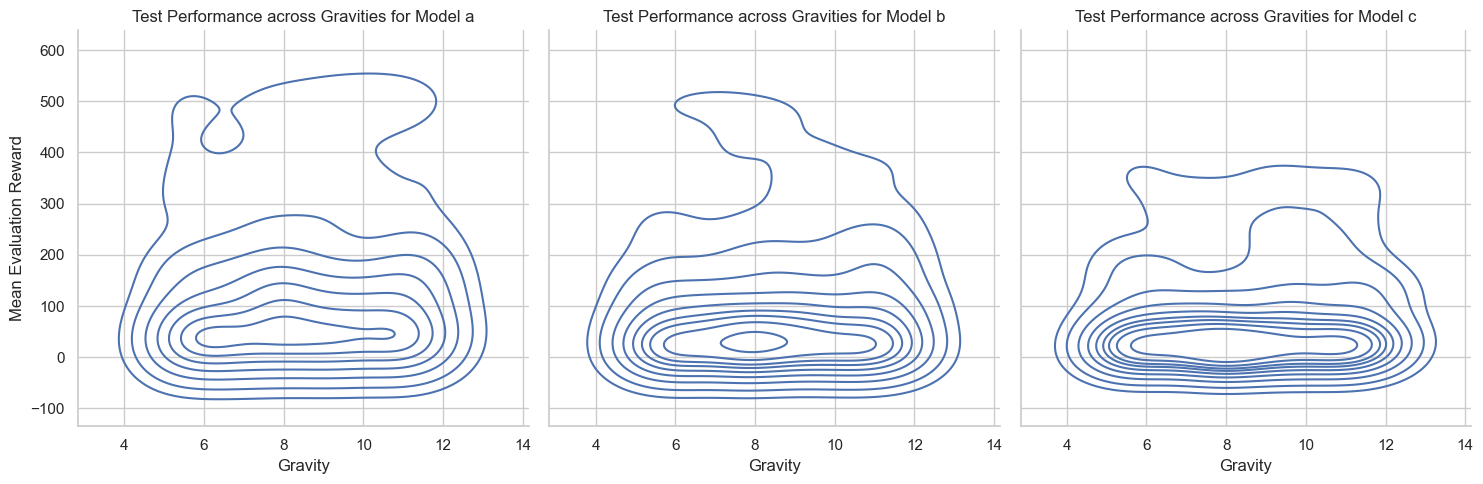

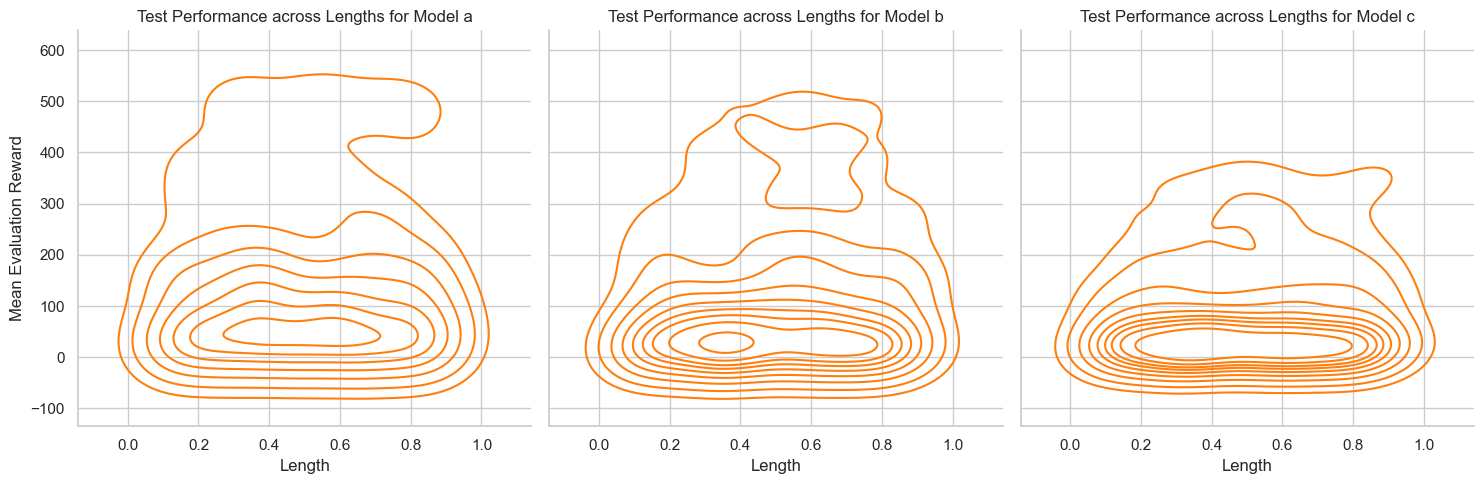

In [20]:
g = sns.displot(data=merged_test_performances, y="mean_eval_reward", x="gravity", col="mode", kind="kde")
g.set_axis_labels("Gravity", "Mean Evaluation Reward")
g.set_titles(col_template="Test Performance across Gravities for Model {col_name}")
g = sns.displot(data=merged_test_performances, y="mean_eval_reward", x="length", color="tab:orange", col="mode", kind="kde")
g.set_axis_labels("Length", "Mean Evaluation Reward")
g.set_titles(col_template="Test Performance across Lengths for Model {col_name}")

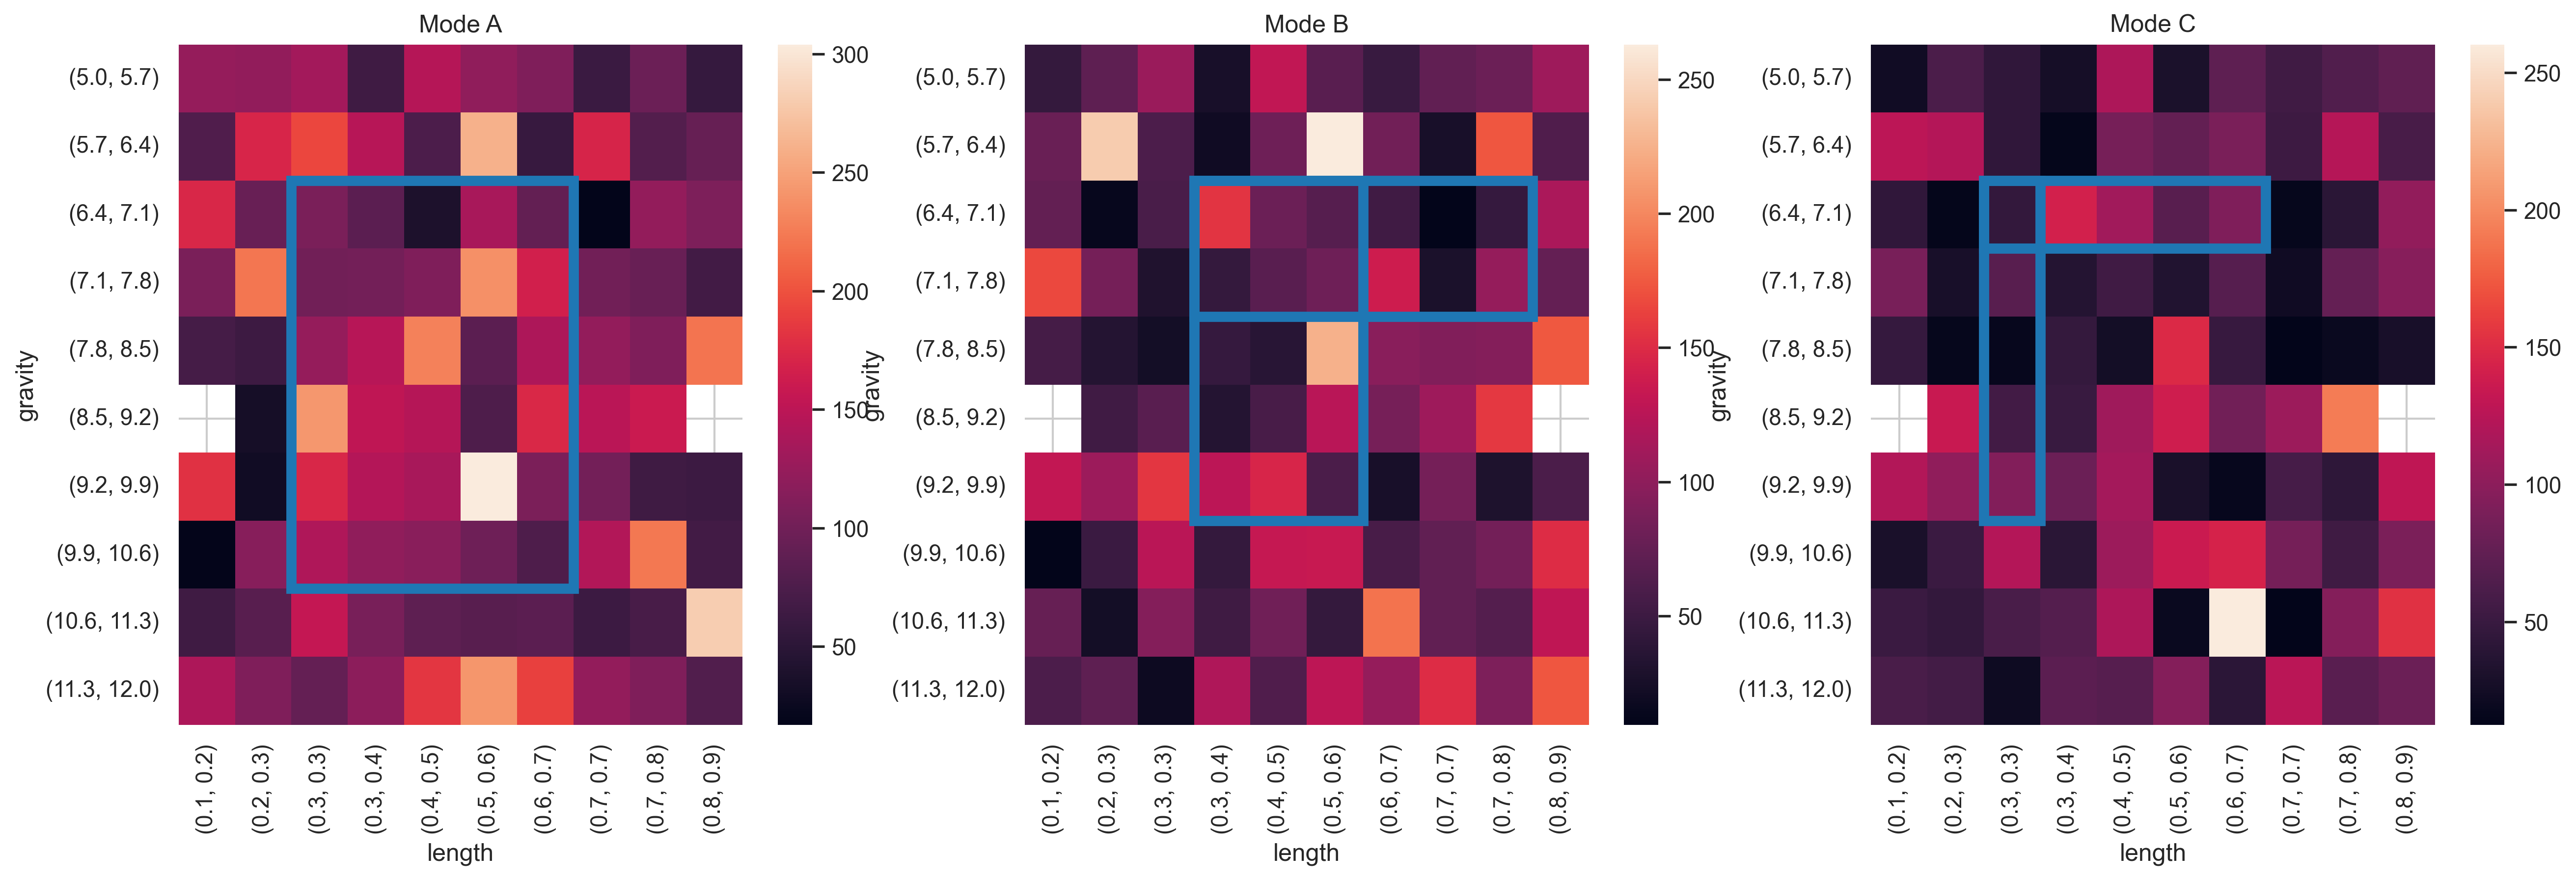

In [21]:
f = make_generalization_plot(test_performances=merged_test_performances, context_feature_names=["gravity", "length"], context_feature_limits={"gravity": [5, 12, 8.5, 7], "length": [0.1, 0.9, 0.5, 0.3]}, train_contexts=train_contexts)